In [63]:

import os
import re

import pandas as pd
import numpy as np


from matplotlib.lines import Line2D

import matplotlib.pyplot as plt

In [64]:
def _format_bytes(bytes):
    if bytes < 1000:
        return f"{bytes} B"
    elif bytes < 1000**2:
        return f"{bytes // 1000} KiB"
    elif bytes < 1000**3:
        return f"{bytes // 1000**2} MiB"
    elif bytes < 1000**4:
        return f"{bytes // 1000**3} GiB"
    else:
        return f"{bytes // 1000**4} TiB"

def get_alternative_rows_label(rows):
    elemts_per_row = 10
    bytes_per_element = 4 # float32
    return [f"{_format_bytes(rows * elemts_per_row * bytes_per_element)} ({rows} rows)"]

       rows  alloc_time_ns   put_time_ns   run_time_ns  run_time_2_ns  \
0         1   3.235200e+01  4.694050e+04  6.444773e+04   6.462221e+04   
1        10   7.226400e+01  5.372601e+04  7.266670e+04   7.197670e+04   
2       100   1.098127e+03  5.550232e+04  6.749474e+04   6.711116e+04   
3      1000   5.953536e+03  7.892408e+04  2.448574e+05   8.450732e+04   
4     10000   1.880798e+04  5.569311e+05  3.082346e+05   2.823562e+05   
5    100000   1.318346e+05  5.195021e+06  6.440997e+06   6.406107e+06   
6   1000000   1.368055e+06  7.207634e+07  5.302562e+06   5.011452e+06   
7  10000000   1.913008e+07  8.341705e+08  7.187050e+07   7.227001e+07   

   get_output_time_ns  total_time_ns  
0        4.717242e+04   2.232152e+05  
1        5.405168e+04   2.524934e+05  
2        4.958659e+04   2.407929e+05  
3        7.407219e+04   4.883145e+05  
4        3.293628e+05   1.495693e+06  
5        2.674527e+06   2.084849e+07  
6        2.882920e+07   1.125876e+08  
7        3.626593e+08   1.3601

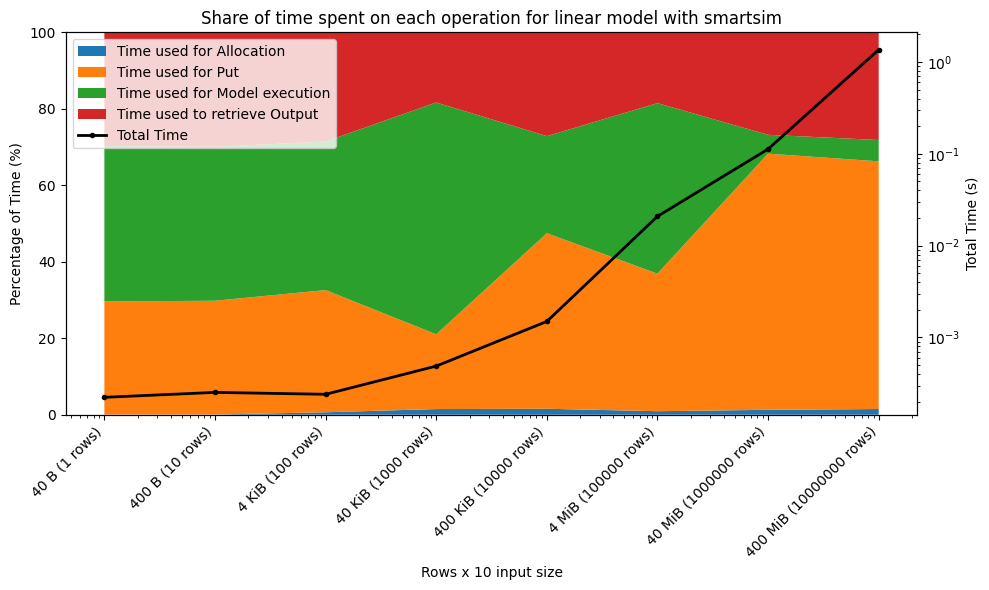

In [72]:
df = pd.read_csv("solver/performance_results.csv")

# group by "rows", get average of all other columns per group
df_combined = df.groupby("rows").mean().reset_index()

print(df_combined)

# Calculate percentages for each time component
df_percentage = df_combined.copy()
df_percentage["total_ns"] = df_combined["total_time_ns"] - df_combined["run_time_2_ns"] # we want to exclude the second run time from the total time for the percentage calculation, since it's not part of the first run
df_percentage["alloc_pct"] = (df_combined["alloc_time_ns"] / df_percentage["total_ns"]) * 100
df_percentage["put_pct"] = (df_combined["put_time_ns"] / df_percentage["total_ns"]) * 100
df_percentage["run_pct"] = (df_combined["run_time_ns"] / df_percentage["total_ns"]) * 100
df_percentage["run_2_pct"] = (df_combined["run_time_2_ns"] / df_percentage["total_ns"]) * 100
df_percentage["get_output_pct"] = (df_combined["get_output_time_ns"] / df_percentage["total_ns"]) * 100

# plot as a stacked line graph with "rows" on the x-axis and y as the percentage axis, the lowest line is alloc_time, then put_time, then run_time, then get_output_time

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(
    df_percentage["rows"],
    df_percentage["alloc_pct"],
    df_percentage["put_pct"],
    df_percentage["run_pct"],
    df_percentage["get_output_pct"],
    labels=["Time used for Allocation", "Time used for Put", "Time used for Model execution", "Time used to retrieve Output"],
)
ax.set_xscale("log")
ax.set_xlabel("Rows x 10 input size")
ax.set_ylabel("Percentage of Time (%)")
ax.set_xticks(df_combined["rows"])
ax.set_xticklabels([get_alternative_rows_label(row)[0] for row in df_combined["rows"]], rotation=45, ha='right')
ax.set_ylim([0, 100])

# Create second y-axis for total time
ax2 = ax.twinx()
ax2.plot(df_combined["rows"], df_combined["total_time_ns"] / 10**9, color='black', marker='.', linewidth=2, label='Total Time')
ax2.set_yscale('log')
ax2.set_ylabel("Total Time (s)")

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Share of time spent on each operation for linear model with smartsim")
plt.tight_layout()

plt.show()

In [66]:
# For each rows value, let's create a histogram of the time used for each step, with the x-axis as the time in seconds and the y-axis as the count of occurrences. We can use a log scale for the x-axis to better visualize the distribution of times.

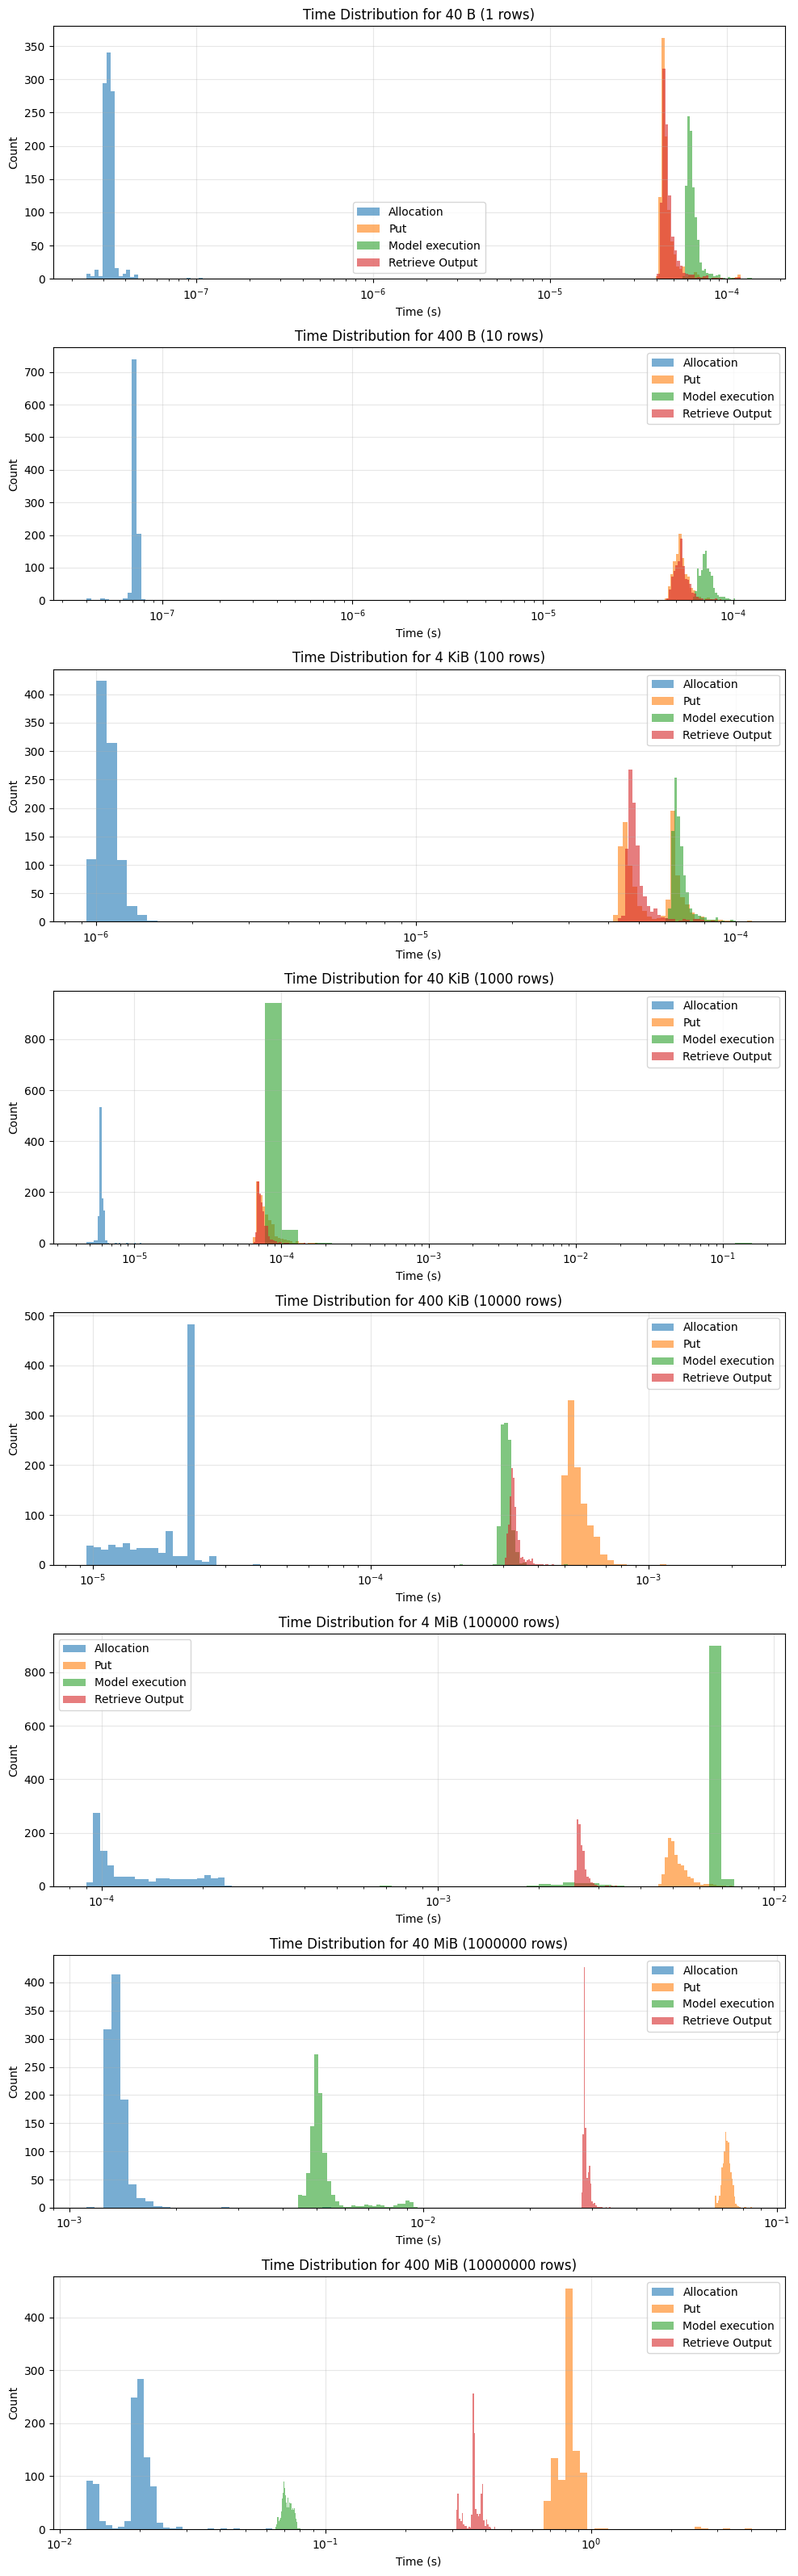

In [80]:
# For each unique rows value, create histograms of the time used for each step
import matplotlib.pyplot as plt

unique_rows = df['rows'].unique()
unique_rows.sort()

# Create subplots for each rows value
fig, axes = plt.subplots(len(unique_rows), 1, figsize=(10, 4*len(unique_rows)))

if len(unique_rows) == 1:
    axes = [axes]

time_columns = ['alloc_time_ns', 'put_time_ns', 'run_time_ns', 'get_output_time_ns']
labels = ["Allocation", "Put", "Model execution", "Retrieve Output"]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for idx, row_val in enumerate(unique_rows):
    df_subset = df[df['rows'] == row_val]
    
    ax = axes[idx]
    
    # Create histogram for each time component with log-spaced bins
    for col, label, color in zip(time_columns, labels, colors):
        times_seconds = df_subset[col] / 10**9
        # Use log-spaced bins to avoid matplotlib's log-scale histogram bug
        bins = np.logspace(np.log10(times_seconds.min()), np.log10(times_seconds.max()), 30)
        ax.hist(times_seconds, bins=bins, alpha=0.6, label=label, color=color)
        
        # Add percentile lines
        #p1 = times_seconds.quantile(0.01)
        #median = times_seconds.median()
        #p99 = times_seconds.quantile(0.99)
        
        #ax.axvline(median, color=color, linestyle='-', linewidth=2, alpha=0.8)
        #ax.axvline(p1, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
        #ax.axvline(p99, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    
    ax.set_xscale('log')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Count')
    ax.set_title(f'Time Distribution for {get_alternative_rows_label(row_val)[0]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


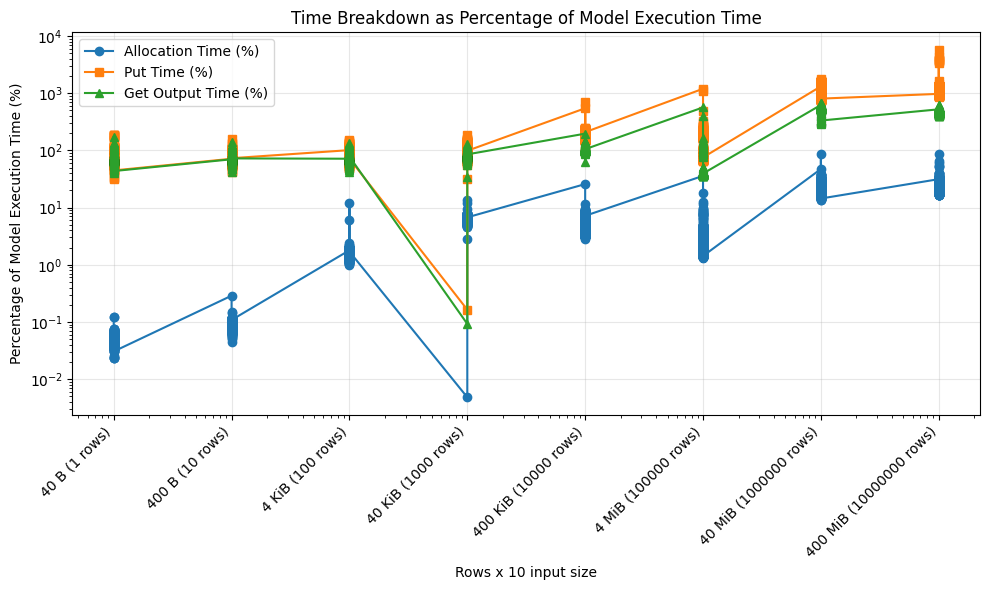

In [68]:
# Let's use the model execution time as the basis for comparison, and plot the time used for allocation, put, and retrieving output as a percentage of the model execution time for each rows value. We use a line chart to visualize this across different rows values.
df_percentage = df.copy()
df_percentage['alloc_time_pct'] = (df_percentage['alloc_time_ns'] / df_percentage['run_time_ns']) * 100
df_percentage['put_time_pct'] = (df_percentage['put_time_ns'] / df_percentage['run_time_ns']) * 100
df_percentage['get_output_time_pct'] = (df_percentage['get_output_time_ns'] / df_percentage['run_time_ns']) * 100

# Plot the percentages for each rows value
plt.figure(figsize=(10, 6))
plt.plot(df_percentage['rows'], df_percentage['alloc_time_pct'], label='Allocation Time (%)', marker='o')
plt.plot(df_percentage['rows'], df_percentage['put_time_pct'], label='Put Time (%)', marker='s')
plt.plot(df_percentage['rows'], df_percentage['get_output_time_pct'], label='Get Output Time (%)', marker='^')

ax = plt.gca()
ax.set_xlabel('Rows x 10 input size')
ax.set_ylabel('Percentage of Model Execution Time (%)')
ax.set_xscale('log')
ax.set_yscale('log')
unique_rows_pct = df_percentage['rows'].unique()
unique_rows_pct.sort()
ax.set_xticks(unique_rows_pct)
ax.set_xticklabels([get_alternative_rows_label(row)[0] for row in unique_rows_pct], rotation=45, ha='right')

plt.title('Time Breakdown as Percentage of Model Execution Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


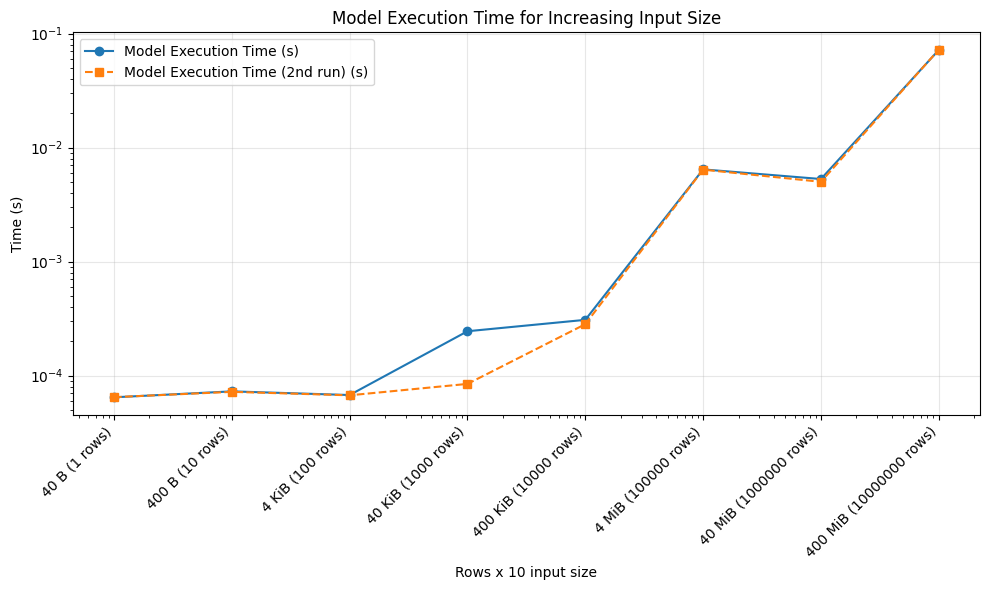

In [69]:
#Let's compare the first and second runs of the model execution time to see if there is any significant difference in the time taken for the first run versus subsequent runs, which could indicate caching effects or other optimizations that occur after the initial execution. We can plot this as a line chart with "rows" on the x-axis and time in seconds on the y-axis, using a log scale for better visualization.
plt.figure(figsize=(10, 6))
plt.plot(df_combined['rows'], df_combined['run_time_ns'] / 10**9, label='Model Execution Time (s)', marker='o')
plt.plot(df_combined['rows'], df_combined['run_time_2_ns'] / 10**9, label='Model Execution Time (2nd run) (s)', linestyle='--', marker='s')
ax = plt.gca()
ax.set_xlabel('Rows x 10 input size')
ax.set_ylabel('Time (s)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(df_combined['rows'])
ax.set_xticklabels([get_alternative_rows_label(row)[0] for row in df_combined['rows']], rotation=45, ha='right')

plt.title('Model Execution Time for Increasing Input Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


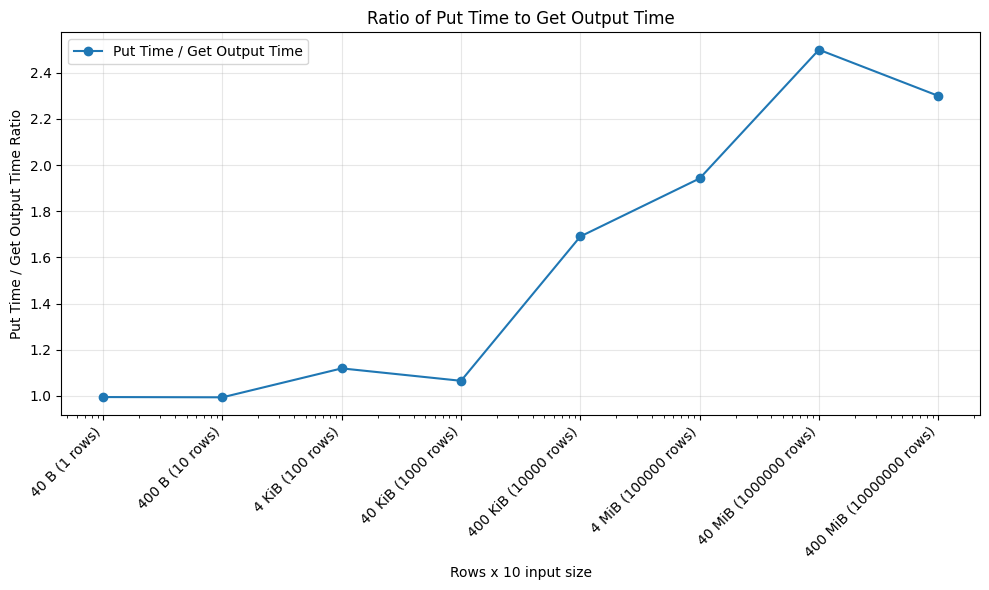

In [70]:
# plot the ratio of put_time_ns to get_output_time_ns for each rows value. as the input size is exactly 10 times the output size, we'd expect roughly a 10x ratio

plt.figure(figsize=(10, 6))
plt.plot(df_combined['rows'], df_combined['put_time_ns'] / df_combined['get_output_time_ns'], label='Put Time / Get Output Time', marker='o')
ax = plt.gca()
ax.set_xscale('log')
ax.set_xlabel('Rows x 10 input size')
ax.set_ylabel('Put Time / Get Output Time Ratio')
ax.set_xticks(df_combined['rows'])
ax.set_xticklabels([get_alternative_rows_label(row)[0] for row in df_combined['rows']], rotation=45, ha='right')

plt.title('Ratio of Put Time to Get Output Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plotting alloc_time_ns...
Plotting put_time_ns...
Plotting run_time_ns...
Plotting run_time_2_ns...
Plotting get_output_time_ns...
Plotting total_time_ns...


<Figure size 8000x6000 with 0 Axes>

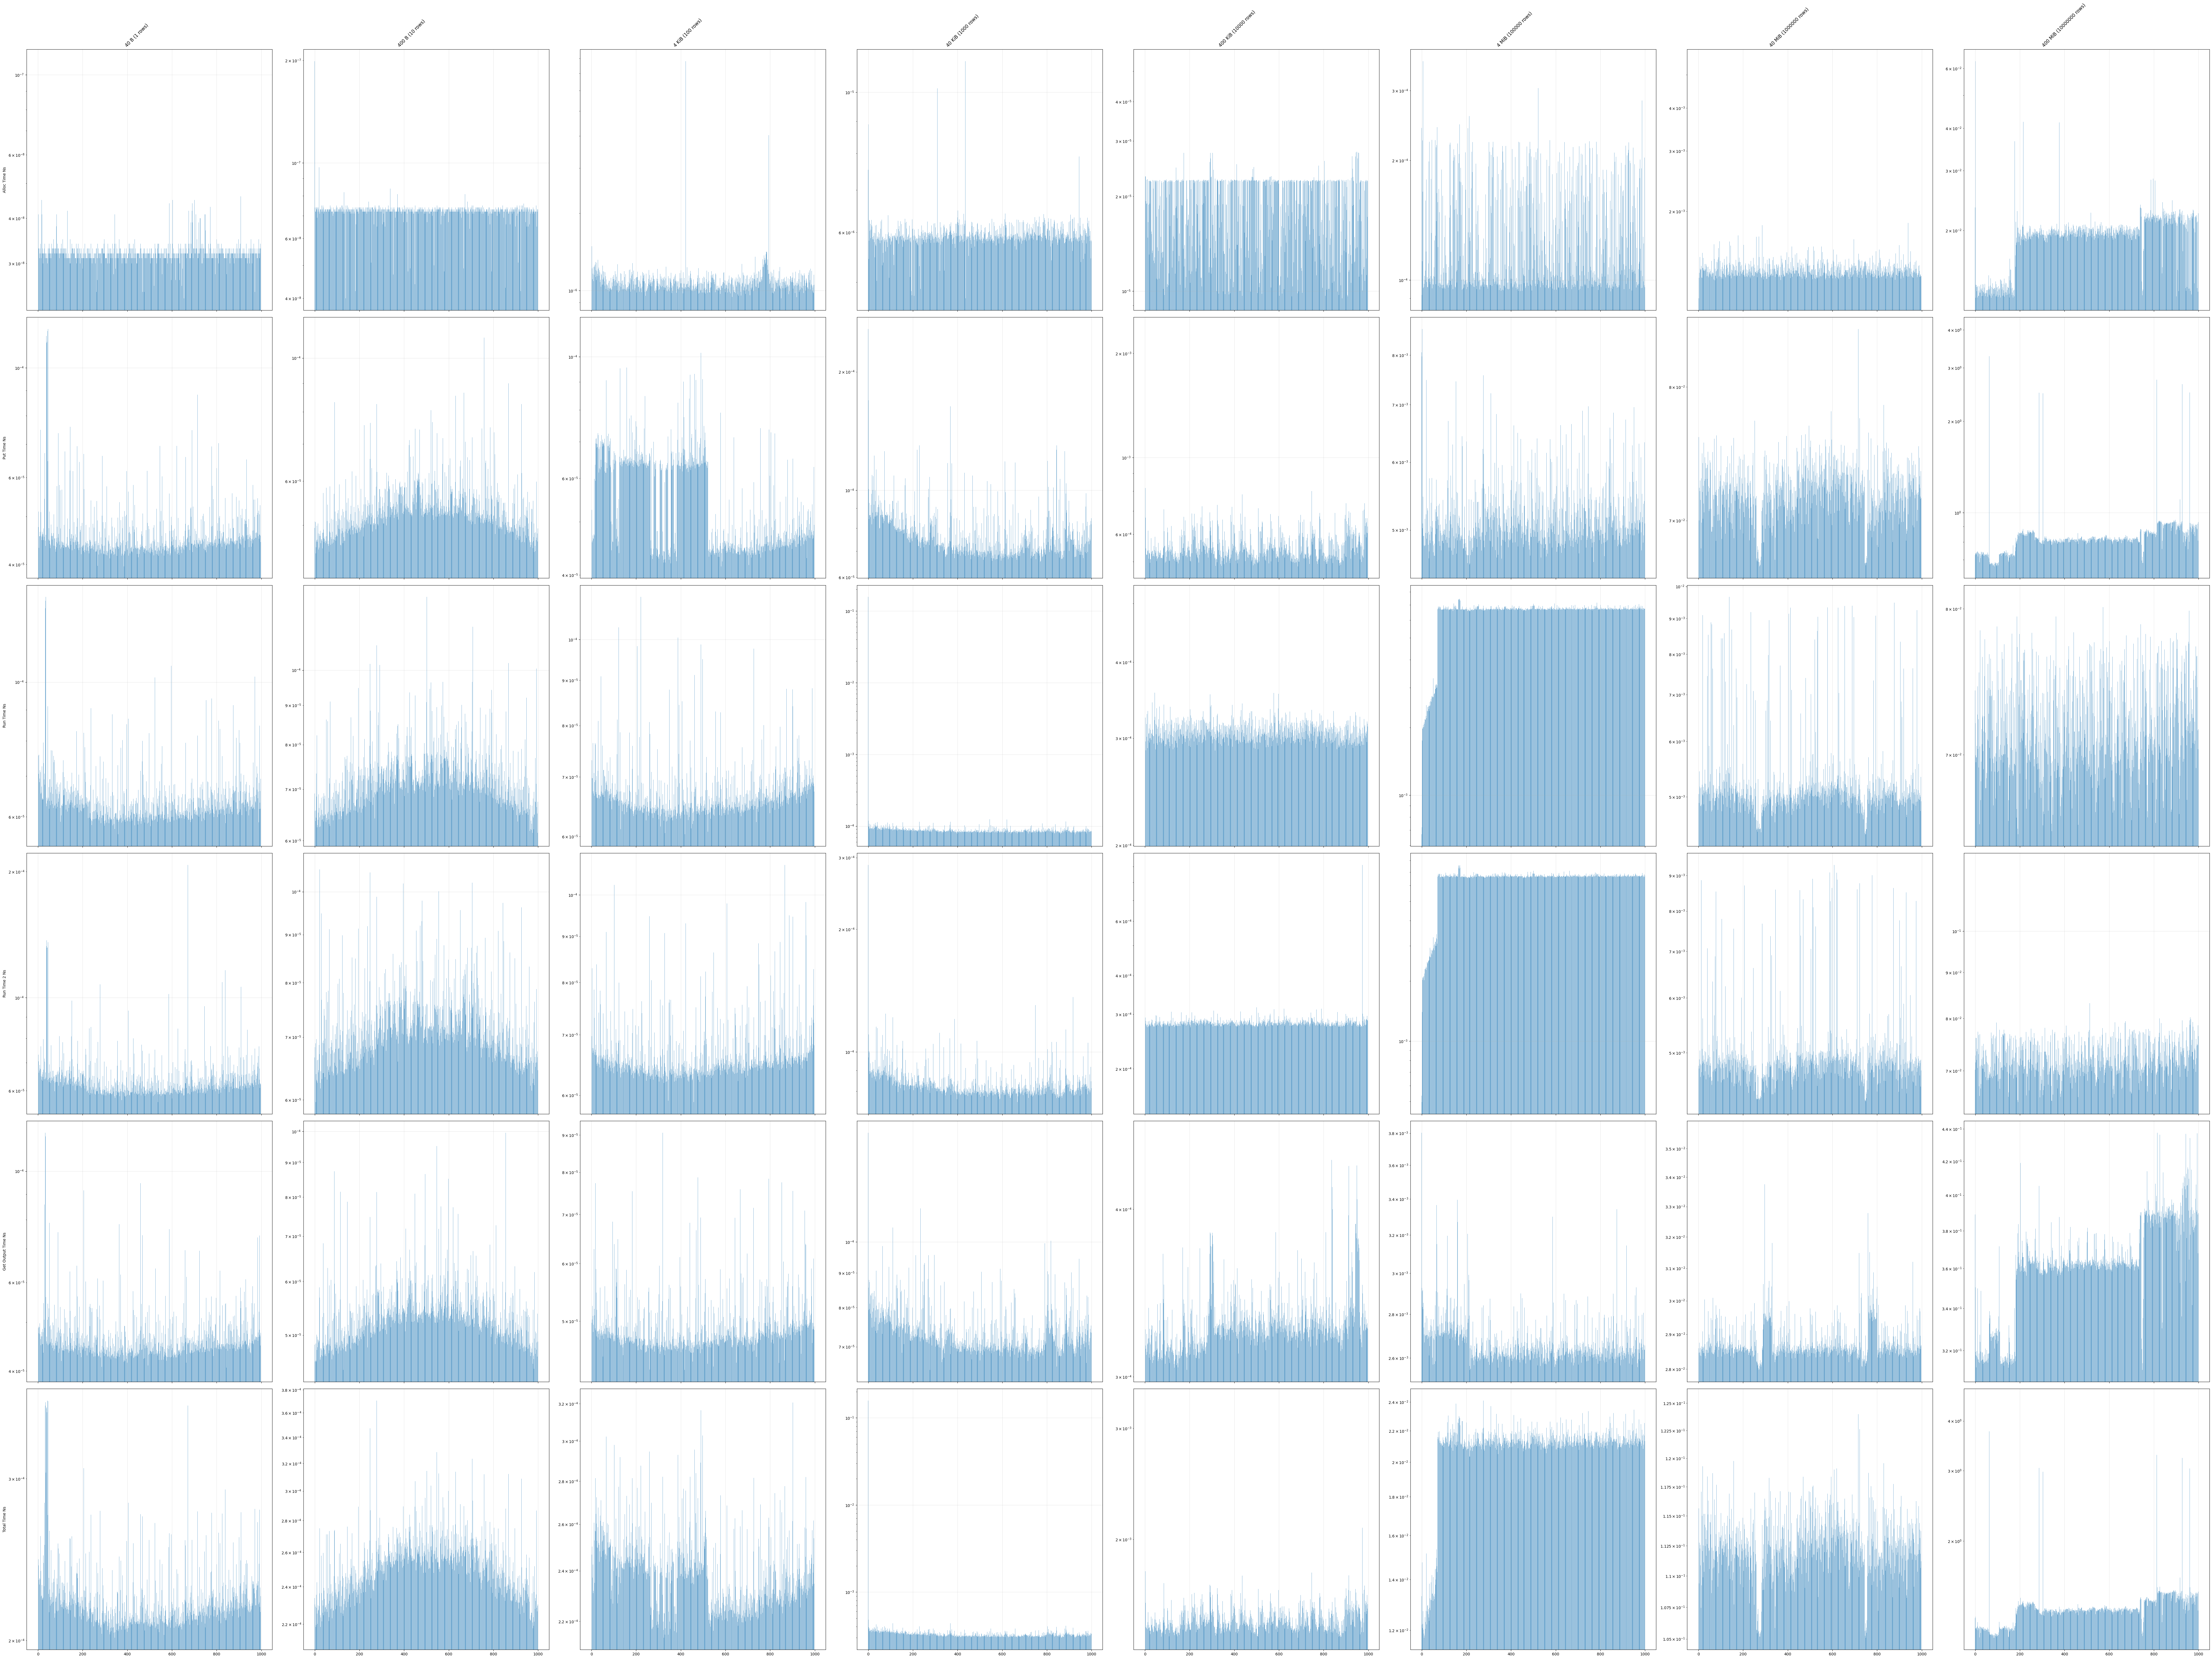

In [71]:
# as we have repeated runs for each rows value, we should plot the times used for step 0 to 999 as a bar so we can see if there are outliers, like if the first run is always significantly higher than the subsequent runs, which could indicate caching effects or other optimizations that occur after the initial execution. We can plot this as a one bar per rows value with the time for step 0 to 999 on the y and x axis respectively, using a log scale for the y-axis to better visualize the distribution of times across different rows values.

# thus, as we have 6 different time components and 8 differnt row values, we can create a grid of 6x8 subplots, where each row corresponds to a time component and each column corresponds to a rows value. In each subplot, we can plot the times for step 0 to 999 as a bar chart, with the x-axis representing the step number and the y-axis representing the time in seconds (using a log scale). This will allow us to visually compare the distribution of times for each time component across different rows values and identify any outliers or trends.

plt.figure(figsize=(80, 60))

fig, axes = plt.subplots(6, 8, figsize=(80, 60), sharex=True)

for i, col in enumerate(['alloc_time_ns', 'put_time_ns', 'run_time_ns', 'run_time_2_ns', 'get_output_time_ns', 'total_time_ns']):
    print(f"Plotting {col}...")
    for j, row_val in enumerate(unique_rows):
        df_subset = df[df['rows'] == row_val]
        times_seconds = df_subset[col] / 10**9
        axes[i, j].bar(range(len(times_seconds)), times_seconds, alpha=0.6)
        axes[i, j].set_yscale('log')
        if i == 0:
            axes[i, j].set_title(get_alternative_rows_label(row_val)[0], rotation=45, ha='right')
        if j == 0:
            axes[i, j].set_ylabel(col.replace('_', ' ').title())
        axes[i, j].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()